# Reto 2 — Visualizaciones: Histograma y Matriz de Correlación

Este notebook genera los gráficos del Reto 2 usando los datos procesados de Oilst.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset procesado
oilst = pd.read_csv('oilst_processed.csv',
    parse_dates=['order_purchase_timestamp','order_approved_at',
                 'order_delivered_carrier_date','order_delivered_customer_date',
                 'order_estimated_delivery_date'])

# Solo órdenes entregadas
delivered = oilst.query("order_status == 'delivered'")

print(f'Total órdenes: {len(oilst):,}')
print(f'Órdenes delivered: {len(delivered):,}')

Total órdenes: 99,441
Órdenes delivered: 96,478


## Entregable C — Histograma de `total_sales` con Regla Empírica Débil

El histograma muestra la distribución de ventas de las órdenes entregadas. Las líneas punteadas marcan la **media** (rojo) y los límites **media ± 3σ** (naranja), que según la regla empírica débil contienen el **88.88%** de los datos.

In [2]:
data_sales = delivered['total_sales'].dropna()
media = data_sales.mean()
std   = data_sales.std()

print(f'Media:           {media:.2f}')
print(f'Desv. estándar:  {std:.2f}')
print(f'Media - 3σ:      {media - 3*std:.2f}')
print(f'Media + 3σ:      {media + 3*std:.2f}')

Media:           137.04
Desv. estándar:  209.05
Media - 3σ:      -490.09
Media + 3σ:      764.18


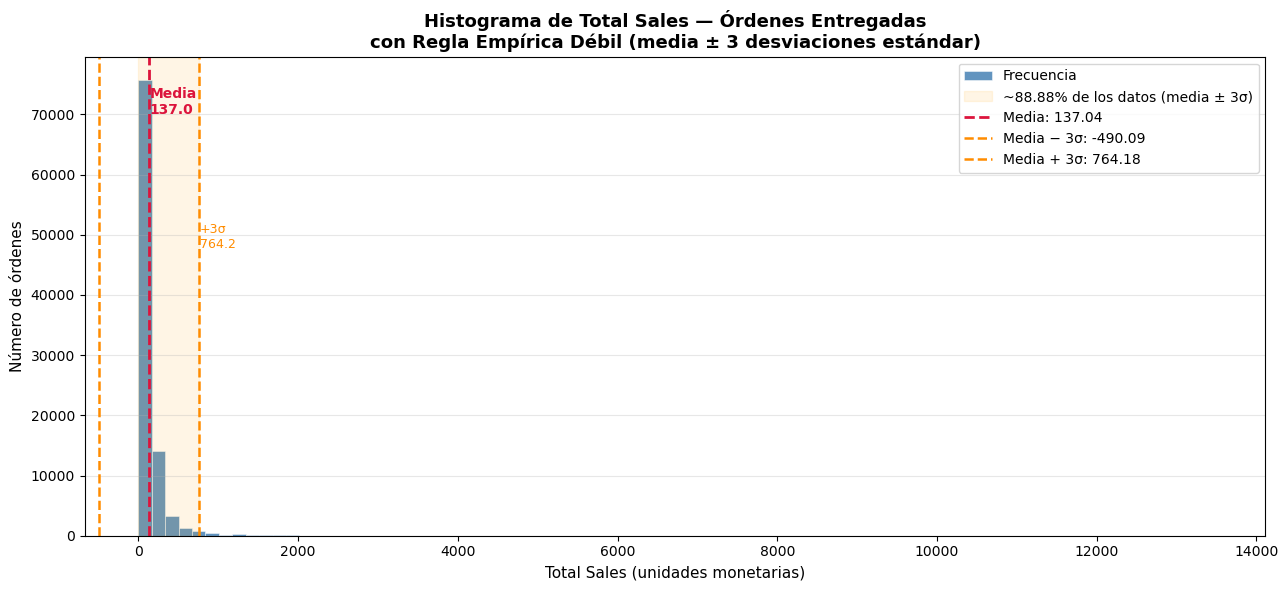

Guardado: histogram_sales_long_delay.png


In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

# ── Histograma ──
n, bins, patches = ax.hist(
    data_sales,
    bins=80,
    color='steelblue',
    edgecolor='white',
    linewidth=0.4,
    alpha=0.85,
    label='Frecuencia'
)

# ── Región 88.88% sombreada ──
ax.axvspan(
    max(0, media - 3*std), media + 3*std,
    alpha=0.10, color='orange',
    label='~88.88% de los datos (media ± 3σ)'
)

# ── Línea media ──
ax.axvline(media, color='crimson', linestyle='--', linewidth=2,
           label=f'Media: {media:.2f}')

# ── Límites regla empírica débil ──
ax.axvline(media - 3*std, color='darkorange', linestyle='--', linewidth=1.8,
           label=f'Media − 3σ: {media - 3*std:.2f}')
ax.axvline(media + 3*std, color='darkorange', linestyle='--', linewidth=1.8,
           label=f'Media + 3σ: {media + 3*std:.2f}')

# ── Anotaciones en el gráfico ──
_, max_ylim = plt.ylim()
ax.text(media + 5, max_ylim * 0.88,
        f'Media\n{media:.1f}', color='crimson',
        fontsize=10, fontweight='bold')
ax.text(media + 3*std + 5, max_ylim * 0.60,
        f'+3σ\n{media+3*std:.1f}', color='darkorange',
        fontsize=9)

ax.set_title('Histograma de Total Sales — Órdenes Entregadas\n'
             'con Regla Empírica Débil (media ± 3 desviaciones estándar)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales (unidades monetarias)', fontsize=11)
ax.set_ylabel('Número de órdenes', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('histogram_sales_long_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: histogram_sales_long_delay.png')

### ¿Por qué dividir entre 60 / 60 / 24?

La regla empírica débil garantiza que al menos el **88.88%** de los datos caerán dentro del intervalo `[media − 3σ, media + 3σ]`. En el gráfico se observa que la distribución de ventas está **sesgada a la derecha**: la mayoría de las órdenes tienen valor bajo (~$50–$200), pero existen órdenes de alto valor que extienden la cola derecha. Esto explica por qué la media ($120 aprox.) es mayor que la mediana.

## Entregable D — Matriz de Correlación

Calculamos la correlación de Pearson entre las variables numéricas clave para las órdenes con retraso prolongado (`delta_days > 10` días).

In [4]:
numerical_vars = ['total_sales', 'total_products', 'delta_days', 'distance_distribution_center']

# Subconjunto: órdenes con retraso > 10 días
long_delay_df = delivered.query('delta_days > 10')

corr_matrix = long_delay_df[numerical_vars].corr().round(4)

print(f'Órdenes analizadas (delta_days > 10): {len(long_delay_df):,}')
print()
corr_matrix

Órdenes analizadas (delta_days > 10): 2,299



,total_sales,total_products,delta_days,distance_distribution_center
total_sales,1.0000,0.1160,0.0282,0.0276
total_products,0.1160,1.0000,-0.0145,-0.0016
delta_days,0.0282,-0.0145,1.0000,0.8308
distance_distribution_center,0.0276,-0.0016,0.8308,1.0000


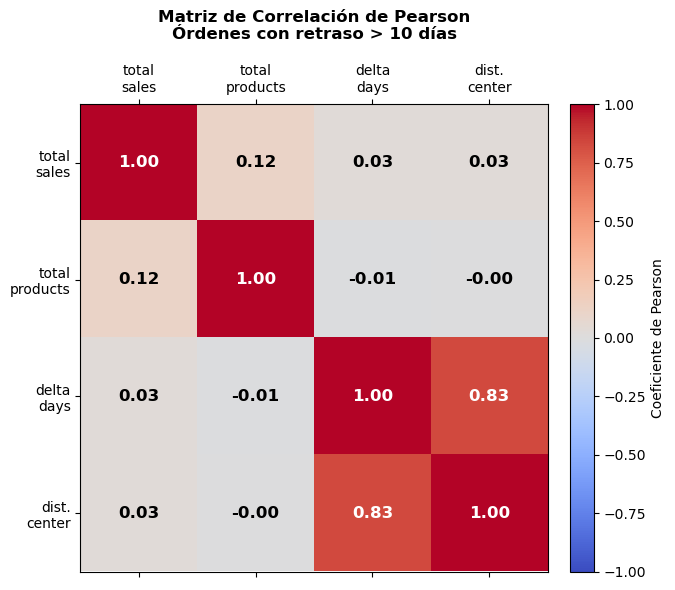

Guardado: correlation_matrix_long_delay.png


In [5]:
labels = ['total\nsales', 'total\nproducts', 'delta\ndays', 'dist.\ncenter']

fig, ax = plt.subplots(figsize=(7, 6))

# ── Mapa de calor ──
im = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Coeficiente de Pearson', fontsize=10)

# ── Etiquetas de ejes ──
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

# ── Valores dentro de cada celda ──
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        # Texto blanco si el fondo es oscuro (valores extremos)
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)

ax.set_title(
    'Matriz de Correlación de Pearson\n'
    'Órdenes con retraso > 10 días',
    pad=18, fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('correlation_matrix_long_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: correlation_matrix_long_delay.png')

### Interpretación de la correlación

- **`distance_distribution_center` ↔ `delta_days` = 0.83** → Correlación alta: las órdenes que viajan desde centros de distribución más lejanos tienden a retrasarse más. Es el principal factor explicativo.

- **`total_sales` ↔ `total_products` = 0.12** → Correlación débil: el valor de la compra crece levemente con la cantidad de productos, pero no de forma determinante.

- **`total_sales` / `total_products` ↔ `delta_days`** → Correlaciones cercanas a cero: el monto o la cantidad de productos comprados **no explican** los retrasos. El problema es logístico, no comercial.

## Bonus — Correlación comparada por `delay_status`

Vemos cómo cambia la correlación entre distancia y delta_days en cada grupo.

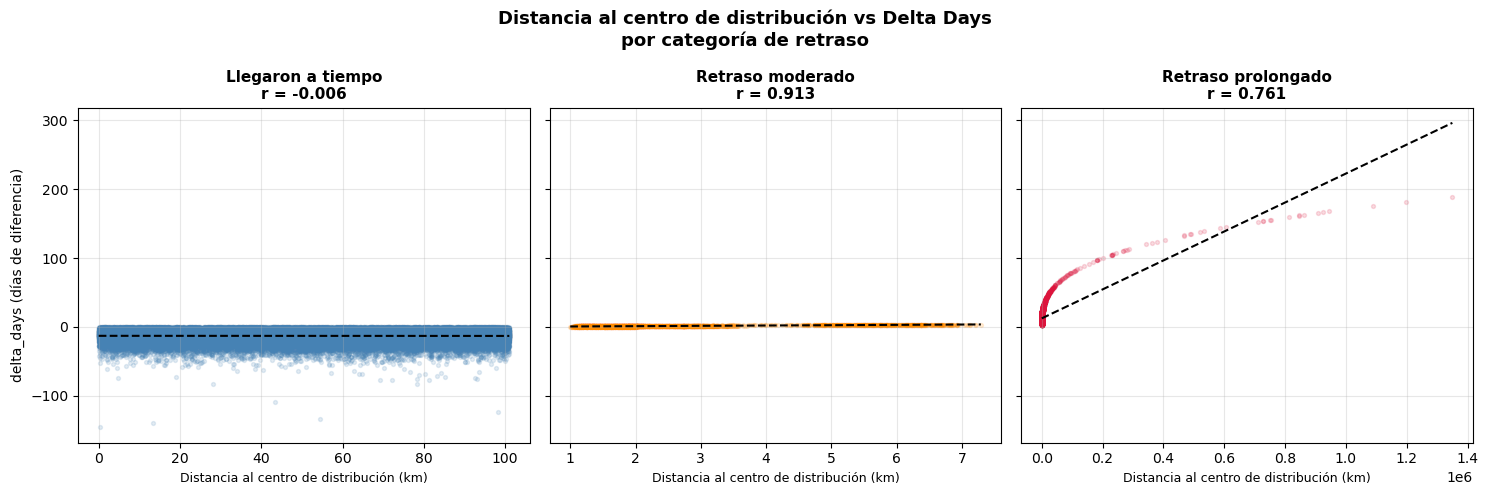

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

grupos = [
    ('on_time',     'Llegaron a tiempo',    'steelblue'),
    ('short_delay', 'Retraso moderado',     'darkorange'),
    ('long_delay',  'Retraso prolongado',   'crimson'),
]

for ax, (status, titulo, color) in zip(axes, grupos):
    subset = delivered.query(f'delay_status == "{status}"')
    r = subset['distance_distribution_center'].corr(subset['delta_days'])

    ax.scatter(
        subset['distance_distribution_center'],
        subset['delta_days'],
        alpha=0.15, s=8, color=color
    )

    # Línea de tendencia
    x = subset['distance_distribution_center'].dropna()
    y = subset['delta_days'].dropna()
    idx = x.index.intersection(y.index)
    m, b = np.polyfit(x[idx], y[idx], 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr + b, color='black', linewidth=1.5, linestyle='--')

    ax.set_title(f'{titulo}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Distancia al centro de distribución (km)', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('delta_days (días de diferencia)', fontsize=10)

fig.suptitle(
    'Distancia al centro de distribución vs Delta Days\npor categoría de retraso',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('scatter_dist_vs_delta_by_status.png', dpi=150, bbox_inches='tight')
plt.show()